# WEEK 1: 光学衛星の基礎 【解答例】

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/astrocamp-2026-siaPpts/astrocamp-2026-sia/blob/main/tutorials/00_example_gee.ipynb)

> **Private リポジトリの注意:**
> このリポジトリは Private 設定のため、上のバッジから直接開けない場合があります。
> その場合は以下の手順で開いてください：
>
> 1. [Google Colab](https://colab.research.google.com/) にアクセス
> 2. 「ファイル」→「ノートブックを開く」→「GitHub」タブ
> 3. 「プライベート リポジトリを含める」にチェックを入れる
> 4. 初回はGitHub認証が求められるので許可する
> 5. リポジトリ `astrocamp-2026-siaPpts/astrocamp-2026-sia` を選択し、該当ノートブックを開く

このノートブックでは Google Earth Engine (GEE) を使って光学衛星データの特性を体験する。


### 学習目標
この演習が終わった後にできること：
1. 衛星が地物を区別できる物理的な理由を説明できる
2. NDVI の意味を式ではなく植物の構造から説明できる
3. 光学センサだけでは解けない課題があることを具体例で言える

### 前提知識
衛星・軌道・電磁波・センサの基礎については、第1回講義資料（CHAPTER 01）を参照すること。

### VSCode で実行する場合
このノートブックは VSCode でも実行できる。以下の手順で環境を準備すること。

1. リポジトリのルートで `uv sync` を実行する（`pyproject.toml` の依存パッケージが `.venv/` にインストールされる）
2. VSCode でカーネルを選択：右上の「カーネルの選択」→ `.venv/bin/python` を選ぶ
3. GEE の認証にはターミナルで事前に `python -c "import ee; ee.Authenticate()"` を実行しておく（ブラウザが開くので許可する）
4. 環境変数 `GEE_PROJECT` を設定しておくと、notebook 内のプロンプトがスキップできる：
   ```bash
   export GEE_PROJECT=ee-yourproject
   code .
   ```

**注意:** 地図はすべて matplotlib で静的に表示されます。Colab/VSCode の両方で同じ結果が得られます。\n

### 実行前に済ませておくこと
1. [GEE アカウント登録](https://earthengine.google.com/) が完了していること。
2. 講義資料（CHAPTER 01）を読んでいること。
3. 自分の GEE プロジェクトID（例: `ee-yourproject`）を確認しておくこと。

### 🕵️ データを探索しよう（推奨）

コードを実行する前に、[Copernicus Browser](https://dataspace.copernicus.eu/browser/) や [VEGA](https://vega.naro.go.jp/) で
福島県相馬市周辺の2024年の衛星画像を眺めてみよう。

**チェックポイント:**
- □ 雲の少ない画像がどの月に多いか確認した
- □ 田んぼに水が入っている時期と収穫後の時期で見え方が違うことを確認した
- □ 「この日付のデータでNDVIを計算してみたい」と思える時期をメモした

> 💡 この事前探索が、あとでGEEのパラメータを自分で調整する時の判断材料になる。
> 「与えられたコードを実行するだけ」ではなく、自分で「どのデータを使うか」を選ぶ習慣をつけよう。

**提出期限: 7/22（火）** — Exercise Log を提出すること（提出方法は下記「Exercise Log の提出」セクションを参照）。

In [1]:
# 必要なライブラリのインストール（Colab 環境の場合）
!pip install geemap earthengine-api

zsh:1: command not found: pip


In [2]:
import ee
import geemap
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from getpass import getpass

# ── 実行環境の判定 ──
_IN_COLAB = 'google.colab' in sys.modules
print(f'実行環境: {"Google Colab" if _IN_COLAB else "VSCode / ローカル"}')

# ── matplotlib 日本語フォント設定 ──
import matplotlib.font_manager as _fm
import platform
if _IN_COLAB:
    import subprocess
    subprocess.run(['apt-get', 'install', '-y', 'fonts-noto-cjk'], capture_output=True)
    _fm._load_fontmanager(try_read_cache=False)
_system = platform.system()
_jp_candidates = {
    'Darwin': ['Hiragino Sans', 'AppleGothic'],
    'Windows': ['Yu Gothic', 'MS Gothic'],
}.get(_system, ['Noto Sans CJK JP', 'IPAexGothic'])
_found = [f for f in _jp_candidates if f in [x.name for x in _fm.fontManager.ttflist]]
if _found:
    plt.rcParams['font.sans-serif'] = _found
else:
    _alt = sorted(set(x.name for x in _fm.fontManager.ttflist
                       if any(c in x.name for c in ['Noto', 'IPA', 'Gothic', 'Yu', 'Hiragino'])))
    if _alt:
        plt.rcParams['font.sans-serif'] = _alt
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# ── GEE プロジェクトIDの設定 ──
# 方法1: 環境変数 GEE_PROJECT が設定されていればそれを使う
GEE_PROJECT = os.environ.get('GEE_PROJECT')
# 方法2: 環境変数がない場合は入力を促す
if not GEE_PROJECT:
    GEE_PROJECT = getpass('GEE プロジェクトIDを入力してください (例: ee-yourproject): ')
print(f'GEE project: {GEE_PROJECT}')

# GEE の認証（初回のみブラウザが開くので許可する）
ee.Authenticate()

# GEE の初期化
print('GEE 初期化中...')
try:
    ee.Initialize(project=GEE_PROJECT)
    print('GEE 初期化成功')
except Exception as e:
    print(f'GEE 初期化エラー: {e}')
    print('プロジェクトIDが正しいか確認してください。')

実行環境: VSCode / ローカル
GEE project: ee-astro2026-mk
GEE 初期化中...
GEE 初期化成功


In [3]:
# ===== 座標設定 =====
# 座標を変更する場合はこのセルだけを編集してください
ROI = ee.Geometry.Rectangle([140.5, 37.2, 141.2, 37.8])
DISPLAY_ROI = ee.Geometry.Rectangle([140.931, 37.790, 140.970, 37.809])
FOREST_PT = ee.Geometry.Point([140.9118, 37.7944])
WATER_PT  = ee.Geometry.Point([140.9780, 37.8000])
BARE_PT   = ee.Geometry.Point([140.9644, 37.8041])
URBAN_PT  = ee.Geometry.Point([140.9278, 37.7925])
FARM_POINT = ee.Geometry.Point([140.9367, 37.7948])
# ====================


In [11]:
# 解析対象の範囲を設定する（福島県浜通り周辺）
# 表示用の小さな領域（matplotlib 描画用）
# Sentinel-2 L2A コレクションを読み込む
collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
# ★ この日付範囲は一例。Copernicus Browser で気になった時期があれば自由に変更して良い
    .filterDate('2025-03-01', '2025-03-30')  # 2024年の生育期
    .filterBounds(DISPLAY_ROI)  # 対象範囲
    .filterMetadata('CLOUDY_PIXEL_PERCENTAGE', 'less_than', 20)  # 雲20%未満
)

print(f'該当画像数: {collection.size().getInfo()}')

# 最も雲の少ない画像を1枚選ぶ
image = collection.sort('CLOUDY_PIXEL_PERCENTAGE').first()
print(f'選択画像: {image.id().getInfo()}')
print(f'撮影日時: {image.date().format("YYYY-MM-dd").getInfo()}')

# 考察（必須）:
# Q. 選ばれたシーンの撮影日はいつか？
#    その日付が「農地のどの生育ステージ」に対応するか、
#    水稲の生育カレンダーに基づいて説明せよ。
# Q. 雲量20%未満という条件を厳しくしすぎると何が起きるか？
#    「観測可能な日数の減少」と「データ品質のトレードオフ」を
#    具体的に説明せよ。
# → ここに考察を書く


該当画像数: 6
選択画像: 20250322T012659_20250322T013247_T54SWG
撮影日時: 2025-03-22


RGB画像を取得中...


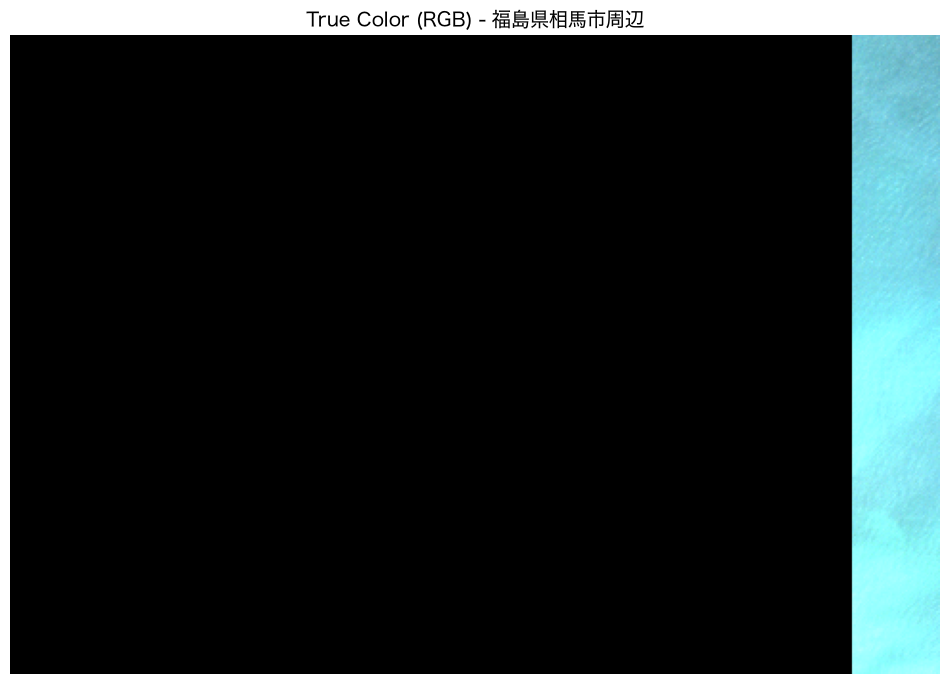

In [12]:
# 真色画像（RGB）を matplotlib で表示
vis_rgb = {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2000}

print('RGB画像を取得中...')
rgb_arr = geemap.ee_to_numpy(image, region=DISPLAY_ROI, bands=['B4', 'B3', 'B2'], scale=20)
vmax = max(np.percentile(rgb_arr, 98), 1)
rgb_display = np.clip(rgb_arr / vmax, 0, 1)

plt.figure(figsize=(12, 10))
plt.imshow(rgb_display)
plt.title('True Color (RGB) - 福島県相馬市周辺', fontsize=14)
plt.axis('off')
plt.show()

# 考察（必須）:
# Q1. Sentinel-2の反射率はなぜ整数値で格納されているのか？
#     （例：反射率0.3が値3000で格納されている理由）
#     浮動小数点で直接格納しない理由を推測せよ。
# Q2. 表示された画像で、農地・森林・水域・市街地はそれぞれ
#     どの色に見えるか？それはスペクトルカーブのどの特性から説明できるか？
# → ここに考察を書く


NDVI 範囲: {'NDVI_max': 0.8807157057654076, 'NDVI_min': -0.2602100350058343}
NDVI画像を取得中...


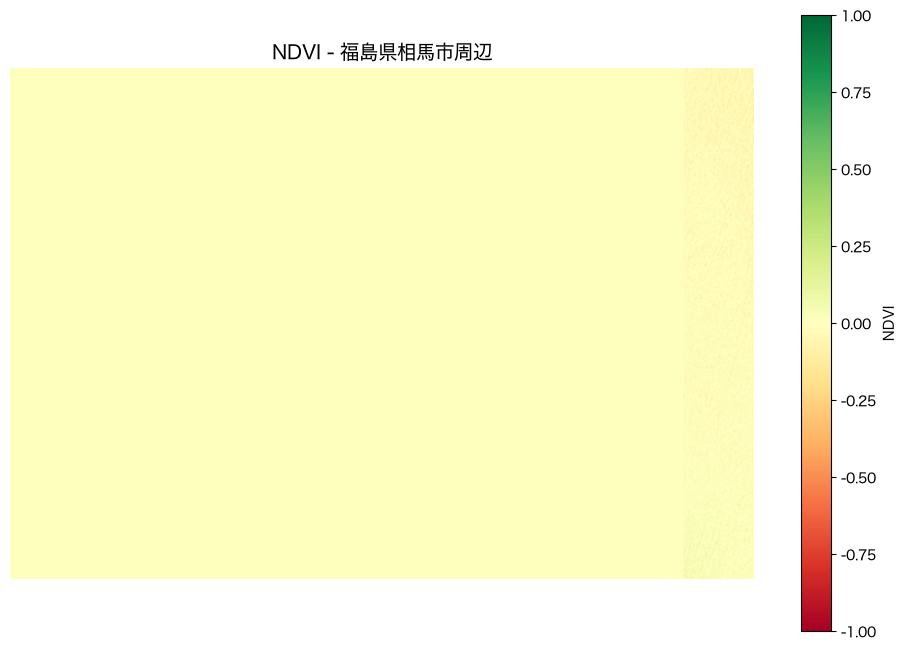

In [6]:
# NDVI = (NIR - Red) / (NIR + Red)
# Sentinel-2 L2A: B8 = NIR (近赤外), B4 = Red (赤)
ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')

# NDVI の統計情報を確認する
stats = ndvi.reduceRegion(
    reducer=ee.Reducer.minMax(),
    geometry=ROI,
    scale=100,
    bestEffort=True
)
print(f'NDVI 範囲: {stats.getInfo()}')

vis_ndvi = {'min': -1, 'max': 1, 'palette': ['blue', 'white', 'green']}

print('NDVI画像を取得中...')
ndvi_arr = geemap.ee_to_numpy(ndvi, region=DISPLAY_ROI, bands=['NDVI'], scale=20)

plt.figure(figsize=(12, 10))
plt.imshow(ndvi_arr.squeeze(), cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(label='NDVI', shrink=0.8)
plt.title('NDVI - 福島県相馬市周辺', fontsize=14)
plt.axis('off')
plt.show()

# 考察（必須）:
# Q1. 計算されたNDVIの最大値・最小値を確認し、
#     「この値が物理的に正しい範囲か」を判断せよ。
#     （例：NDVI > 1.0が出た場合は何かがおかしい）
# Q2. NDVIマップを見て、高い値（緑色）のエリアと
#     低い値（赤色）のエリアを1箇所ずつ特定せよ。
#     Copernicus Browserで同日付の画像を開いて
#     実際に何が写っているか確認し、値と地物が一致しているか検証せよ。
# → ここに考察を書く


In [7]:
# ── AI検証（任意・Exercise Log ②に記録）──
# 以下のプロンプトをChatGPTまたはGeminiに投げてコードを生成させよ。
# 「Google Earth EngineのPython APIを使って、
#  Sentinel-2画像からNDVIを計算するコードを書いてください」
#
# 生成されたコードを見て以下を確認せよ：
# □ バンドの指定方法が自分のコードと一致しているか
# □ normalizedDifference の引数順（[NIR, Red]か[Red, NIR]か）
# □ 生成されたコードに ee.ImageCollection の初期化が含まれているか
#
# 不一致があった場合：どちらが正しいか、物理的根拠から説明せよ。
# （「AIがそう言ったから」ではなく、スペクトルカーブに基づいて判断すること）


---
## NDVI の物理的意味

NDVI は単なる計算式ではない。**葉の内部構造** に物理的な根拠がある。

### なぜ植生は NDVI が高いのか？

| 波長域 | バンド | 植生の応答 | 理由 |
|--------|--------|-----------|------|
| **赤 (Red)** B4 ~665nm | 可視光 | **吸収される**（反射率が低い） | 葉緑素（クロロフィル）が光合成のために赤色光を強く吸収する |
| **近赤外 (NIR)** B8 ~842nm | 不可視 | **強く反射される**（反射率が高い） | 葉の内部の海綿状組織（細胞壁と空気の境界）で多重散乱が起きるため |

→ （NIR - Red）/（NIR + Red） は **植生があると 1 に近づき、ないと 0 以下になる**。

### Sentinel-2 の主要バンドと農地解析

| バンド | 波長 | 農地解析での使い道 |
|-------|------|------------------|
| **B4 (Red)** | 665nm | クロロフィル吸収 → NDVI の赤成分 |
| **B8 (NIR)** | 842nm | 葉構造散乱 → NDVI の近赤外成分 |
| **B11 (SWIR1)** | 1610nm | 土壌・水分の影響を検出（NDWI などに利用） |
| **B12 (SWIR2)** | 2190nm | 鉱物・土壌の種類の判別に有効 |

> 💡 B11 / B12 は植生と土壌の区別や、収穫後の裸地判定に役立つ。次週以降の SAR との組み合わせでも重要。

---
## スペクトルプロファイルを確認する

実際の画像から、植生・水域・裸地・都市の 4 地点における分光反射率の特徴を確認しよう。

In [8]:
# 各地物タイプの代表点を定義する（経度, 緯度）
# 植生（森林）: 阿武隈高地東縁（松川浦沿岸クロマツ林）
# 水域: 松川浦（潟湖）
# 裸地: 農地（収穫後）
# 都市: 相馬市中村市街地

points = {
    '森林 (Forest)': FOREST_PT,
    '水域 (Water)': WATER_PT,
    '裸地 (Bare)': BARE_PT,
    '都市 (Urban)': URBAN_PT,
}

# 抽出するバンド（可視〜SWIR）
bands = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B11', 'B12']
band_centers = [490, 560, 665, 705, 740, 783, 842, 1610, 2190]  # 中心波長 (nm)

# 各地点の反射率を取得
spectra = {}
for name, pt in points.items():
    # reduceRegion + buffer で確実にピクセル値を取得
    values = image.select(bands).reduceRegion(
        reducer=ee.Reducer.first(),
        geometry=pt.buffer(50),
        scale=10
    ).getInfo()
    if values is None:
        print(f'{name}: データなし')
        continue
    # 各バンドの値を取り出す（スケーリングファクタ 10000 で割って反射率に）
    refl = []
    for b in bands:
        val = values.get(b, None)
        if val is not None:
            refl.append(val / 10000)
        else:
            refl.append(None)
    spectra[name] = refl
    print(f'{name}: B4(Red)={refl[2]:.3f}, B8(NIR)={refl[6]:.3f}')

# プロットする
plt.figure(figsize=(12, 5))
for name, refl in spectra.items():
    if refl:
        plt.plot(band_centers, refl, marker='o', label=name)

plt.xlabel('波長 (nm)')
plt.ylabel('反射率')
plt.title('Sentinel-2 分光反射率プロファイル（福島県浜通り）')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

TypeError: unsupported format string passed to NoneType.__format__

### スペクトルプロファイルの解釈

- **森林**: Red で吸収され NIR で強く反射 → 典型的な植生カーブ。NDVI が高い。
- **水域**: 全波長域で反射率が低い（特に NIR 以降でほぼゼロ）。NDVI は負の値。
- **裸地**: 全波長でなだらかな反射。植生のような NIR のピークはない。
- **都市**: 全体的に中程度の反射。コンクリートやアスファルトの影響。

> 💡 このカーブの「形」が地物を識別する手がかりになる。機械学習ではこのプロファイル全体を特徴量として使うこともある。

---
## 光学センサの限界

光学衛星には以下の **4 つの決定的な限界** がある。これが、次週以降に SAR（合成開口レーダー）を学ぶ理由になる。

### ① 雲を通り抜けられない
可視光・赤外線を使う光学センサは雲の上から地表を見ることができない。福島のような日本沿岸部は特に春季〜秋季に曇天が多く、年間の利用可能画像数が限られる。東北地方の夏季（7〜8月）の平均雲量は約70〜80%で、農地の生育ピーク時期と重なる。

### ② 夜間は観測できない
太陽光の反射を観測する光学センサは夜間のデータが取れない。火災・洪水など夜間の緊急事態には対応できないが、能動センサである SAR はこれを補える。

### ③ 収穫後の農地と休耕地が区別しにくい
収穫後は裸地となり NDVI が低下する。この「NDVI が低い」状態だけでは「休耕（年間を通じて低い）」と「収穫後の一時的な裸地」を区別できない。1時期の NDVI だけでは判断が不可能であり、時系列での変化パターンが必要になる。

### ④ 季節変動が大きく1時期では判断できない
農地の NDVI は作付け時期にしか高くならない。1月は低く、5月に上昇、7月にピーク、10月に急落（収穫後）、12月に低くなる。複数時期のデータが必要だが、雲で使えるシーンが少ない月も存在する。

---

### 実際に雲の影響を確認してみよう

雲の多い画像をわざと選んで、NDVI 計算にどのような影響が出るか見てみる。

雲80%以上の画像数: 11
選択画像: 20240602T011659_20240602T011653_T54SVG
雲被覆率: 87.84821%
雲あり画像を取得中...


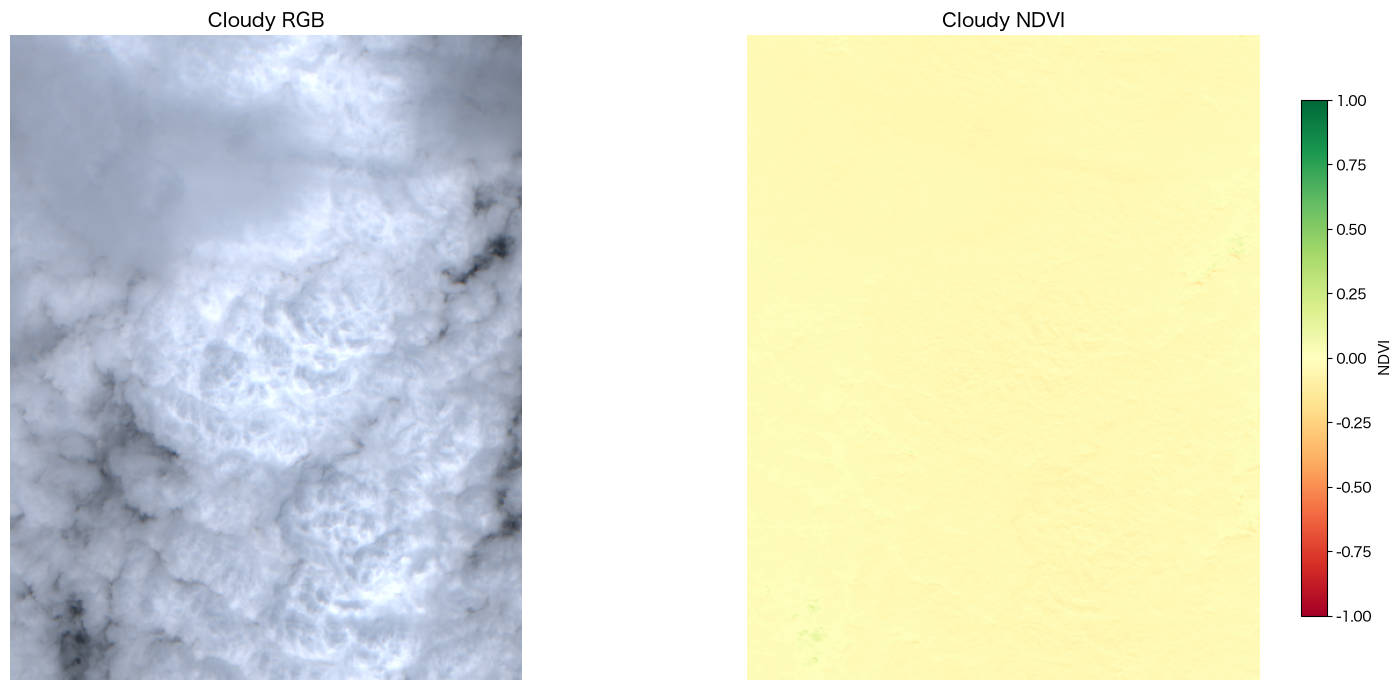

In [ ]:
# 雲の多い画像（雲80%以上）をあえて選ぶ
cloudy_collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2024-06-01', '2024-06-30')
    .filterBounds(ROI)
    .filterMetadata('CLOUDY_PIXEL_PERCENTAGE', 'greater_than', 80)
)

print(f'雲80%以上の画像数: {cloudy_collection.size().getInfo()}')

if cloudy_collection.size().getInfo() > 0:
    cloudy_image = cloudy_collection.first()
    print(f'選択画像: {cloudy_image.id().getInfo()}')
    print(f'雲被覆率: {cloudy_image.get("CLOUDY_PIXEL_PERCENTAGE").getInfo()}%')

    # 雲の多い画像の NDVI を計算
    ndvi_cloudy = cloudy_image.normalizedDifference(['B8', 'B4']).rename('NDVI_cloudy')

    print('雲あり画像を取得中...')
    rgb_cloudy = geemap.ee_to_numpy(cloudy_image, region=DISPLAY_ROI, bands=['B4', 'B3', 'B2'], scale=20)
    ndvi_cloudy_arr = geemap.ee_to_numpy(ndvi_cloudy, region=DISPLAY_ROI, bands=['NDVI_cloudy'], scale=20)
    vmax_c = max(np.percentile(rgb_cloudy, 98), 1)
    rgb_cloudy_disp = np.clip(rgb_cloudy / vmax_c, 0, 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(rgb_cloudy_disp)
    axes[0].set_title('Cloudy RGB', fontsize=14)
    axes[0].axis('off')
    im = axes[1].imshow(ndvi_cloudy_arr.squeeze(), cmap='RdYlGn', vmin=-1, vmax=1)
    axes[1].set_title('Cloudy NDVI', fontsize=14)
    axes[1].axis('off')
    fig.colorbar(im, ax=axes[1], shrink=0.8, label='NDVI')
    plt.tight_layout()
    plt.show()
else:
    print('6月に雲80%以上の画像が見つかりませんでした。')
    print('以下のいずれかを試してみましょう：')
    print('1. 期間を梅雨の時期（2024-06-01〜2024-08-31）に広げる')
    print('2. 閾値を70%以上に下げる')
    print('3. 元の collection から最も雲が多い画像を逆順ソートで取得する')
    print('→ どの方法を試したか、なぜそれを選んだかをExercise Logに記録すること')


---
## ⭐ チャレンジ課題（発展・任意）

以下の課題は、**福島の農地解析（作付変化・休耕地検出）という本ゼミのメインタスクに直結するスキル** を養うためのもの。
**最低 2 問以上** に挑戦し、結果を Exercise Log のセクション④に記録しよう。

| # | 課題 | なぜ重要か |
|---|------|-----------|
| C1 | 複数時期の NDVI 比較 | 休耕地は生育期に NDVI ピークが立たない → 時系列の基本 |
| C2 | SCL を使った雲・影マスキング | 時系列解析にはピクセル単位の雲除去が必須 |
| C3 | NDVI 時系列グラフ（年間） | 作物の生育サイクル全体を把握する |
| C4 | NDVI 閾値分類による簡易土地被覆図 | 植生/裸地/水域の面的な分布を定量評価 |
| C5 | 任意の農地区画を囲んで NDVI 統計取得 | 実際の農地ポリゴン解析の予行演習 |

---
### ⭐ C1: 複数時期の NDVI 比較

**ねらい:** 同じ場所の異なる時期の NDVI を比較し、作付けの有無による違いを観察する。
**本タスクとの関係:** 休耕地は作付け時期（5〜7月）に NDVI のピークが立たない。この「ピークの有無」が最も基本的な休耕判定指標。

春 (Spring): 撮影日 2024-04-13
夏 (Summer): 撮影日 2024-07-22
秋 (Autumn): 撮影日 2024-10-15
各時期の NDVI を取得中...


/var/folders/3h/xltdqn1n5774zlkq1ygy0szh0000gn/T/ipykernel_88892/1073897883.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


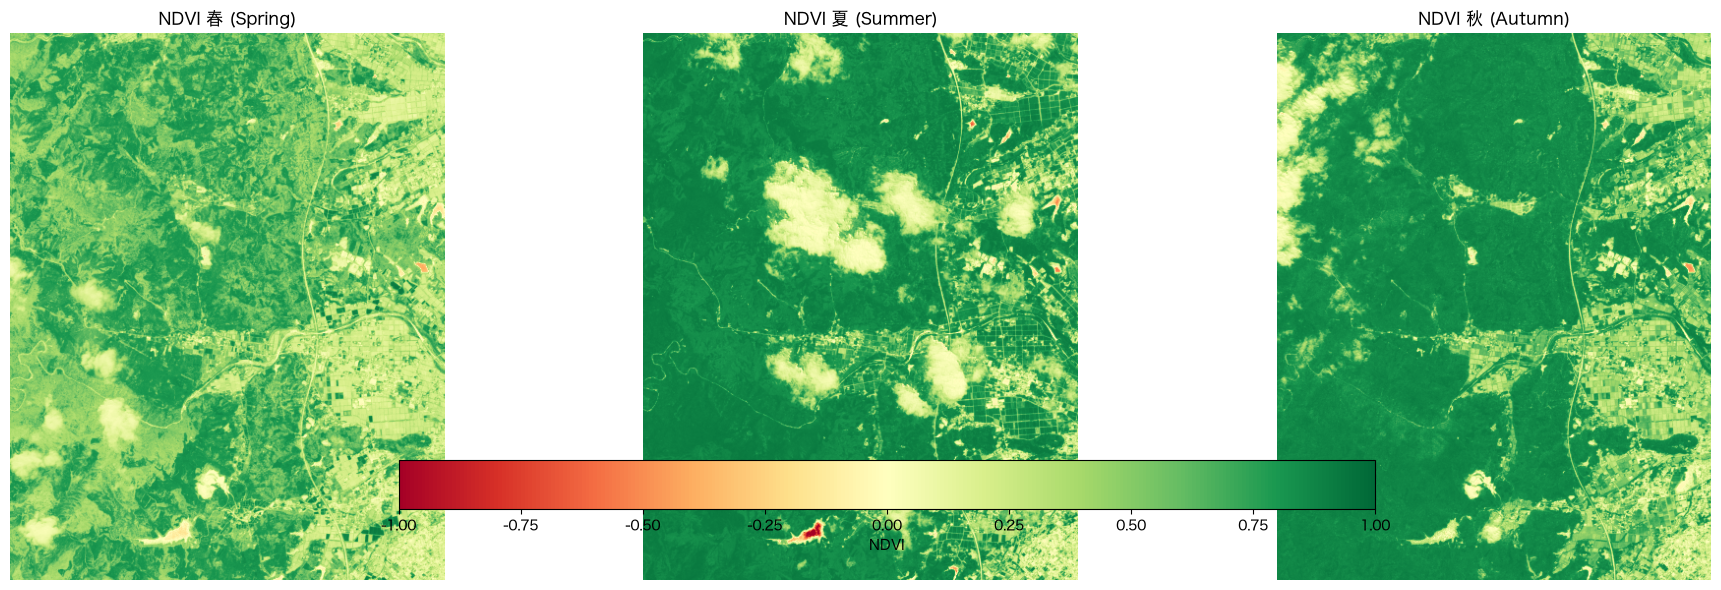

In [ ]:
# 3 つの異なる時期の画像を取得
periods = [
    ('2024-04-01', '2024-04-30', 'Spring', '春'),
    ('2024-07-01', '2024-07-31', 'Summer', '夏'),
    ('2024-10-01', '2024-10-31', 'Autumn', '秋'),
]

images = []
for start, end, eng, jp in periods:
    label = f'{jp} ({eng})'
    col = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterDate(start, end)
        .filterBounds(DISPLAY_ROI)
        .filterMetadata('CLOUDY_PIXEL_PERCENTAGE', 'less_than', 30)
    )
    count = col.size().getInfo()
    if count == 0:
        print(f'{label}: 該当画像なし')
        continue
    img = col.sort('CLOUDY_PIXEL_PERCENTAGE').first()
    ndvi_img = img.normalizedDifference(['B8', 'B4']).rename(f'NDVI_{eng}')
    images.append((label, ndvi_img, f'NDVI_{eng}'))
    print(f'{label}: 撮影日 {img.date().format("YYYY-MM-dd").getInfo()}')

# 3 時期の NDVI を matplotlib で並べて表示
if len(images) >= 2:
    print('各時期の NDVI を取得中...')
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 6))
    if n == 1:
        axes = [axes]
    im = None
    for ax, (label, ndvi_img, band_name) in zip(axes, images):
        arr = geemap.ee_to_numpy(ndvi_img, region=DISPLAY_ROI, bands=[band_name], scale=20)
        im = ax.imshow(arr.squeeze(), cmap='RdYlGn', vmin=-1, vmax=1)
        ax.set_title(f'NDVI {label}', fontsize=12)
        ax.axis('off')
    fig.colorbar(im, ax=axes, orientation='horizontal', shrink=0.6, pad=0.05, label='NDVI')
    plt.tight_layout()
    plt.show()
else:
    print('比較できる画像が不足しています。期間を調整して再実行してみよう。')

# 考察（必須）:
# Q1. 春・夏・秋のNDVIを比べて、最も高い時期はいつか？
#     これは水稲の生育カレンダーと一致しているか確認せよ。
# Q2. 秋（収穫後）のNDVIと春（移植前）のNDVIが似た値になる場合がある。
#     この2つを「休耕地」と間違えないためには何が必要か？
#     「多時期データのどのパターンを見れば休耕地と区別できるか」を説明せよ。
# → ここに考察を書く


---
### ⭐ C2: SCL を使った雲・影マスキング

**ねらい:** 画像全体を捨てるのではなく、雲や影のピクセルだけを取り除く技法を身につける。
**本タスクとの関係:** 複数時期の NDVI 時系列を作るには、曇りのないクリーンなピクセルだけを残す処理が不可欠。

雲マスク比較画像を取得中...


/var/folders/3h/xltdqn1n5774zlkq1ygy0szh0000gn/T/ipykernel_88892/1747800768.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


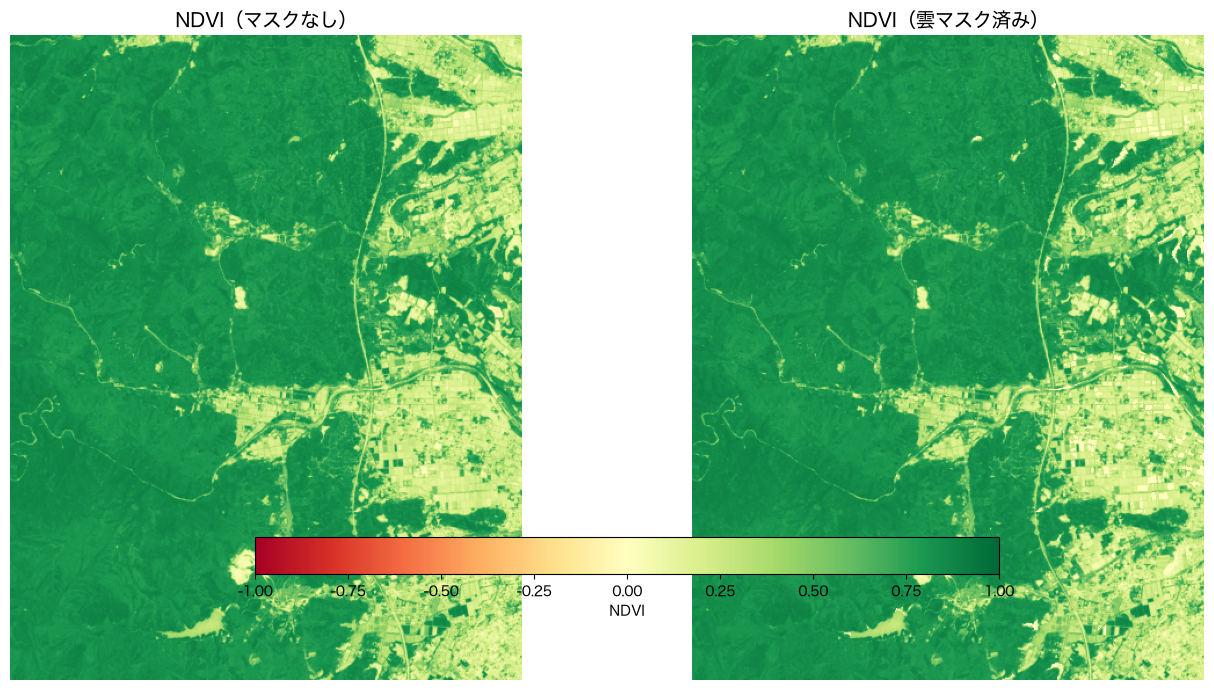

In [ ]:
# Sentinel-2 L2A には Scene Classification Layer (SCL) という分類バンドが含まれている
# SCL のクラス値: 4=植生, 5=裸地, 6=水, 7=低確信度雲, 8=中確信度雲, 9=高確信度雲, 3=雲の影

# 雲と影のクラスをマスクする関数
# Sentinel-2 SCL（Scene Classification Layer）のクラス番号:
# 1: 飽和・欠落  2: 暗い植生  3: 雲の影  4: 植生  5: 裸地
# 6: 水  7: 低い確率の雲  8: 中程度の確率の雲  9: 高い確率の雲
# 10: 薄い雲（巻雲）  11: 雪・氷
# → 除去したいクラス番号はどれか？関数のコードと照合せよ

def mask_clouds_scl(image):
    scl = image.select('SCL')
    # 雲 (7,8,9) と雲の影 (3) をマスク
    cloud_mask = scl.updateMask(scl.neq(3).And(scl.neq(7).And(scl.neq(8).And(scl.neq(9)))))
    return image.updateMask(cloud_mask)

# 通常の画像と SCL マスク済みの画像を比較
normal_image = collection.sort('CLOUDY_PIXEL_PERCENTAGE').first()
masked_image = mask_clouds_scl(normal_image)

ndvi_normal = normal_image.normalizedDifference(['B8', 'B4']).rename('NDVI_normal')
ndvi_masked = masked_image.normalizedDifference(['B8', 'B4']).rename('NDVI_masked')

print('雲マスク比較画像を取得中...')
ndvi_norm_arr = geemap.ee_to_numpy(ndvi_normal, region=DISPLAY_ROI, bands=['NDVI_normal'], scale=20)
ndvi_mask_arr = geemap.ee_to_numpy(ndvi_masked, region=DISPLAY_ROI, bands=['NDVI_masked'], scale=20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
im0 = axes[0].imshow(ndvi_norm_arr.squeeze(), cmap='RdYlGn', vmin=-1, vmax=1)
axes[0].set_title('NDVI（マスクなし）', fontsize=14)
axes[0].axis('off')
im1 = axes[1].imshow(ndvi_mask_arr.squeeze(), cmap='RdYlGn', vmin=-1, vmax=1)
axes[1].set_title('NDVI（雲マスク済み）', fontsize=14)
axes[1].axis('off')
fig.colorbar(im1, ax=axes, orientation='horizontal', shrink=0.6, pad=0.05, label='NDVI')
plt.tight_layout()
plt.show()

---
### ⭐ C3: NDVI 時系列グラフ

**ねらい:** 1 点の NDVI が 1 年を通してどのように変化するか、グラフで可視化する。
**本タスクとの関係:** 作付された農地では夏に NDVI の山ができる。休耕地では一年中低い値が続く。この「時系列パターン」が休耕判定の根拠。

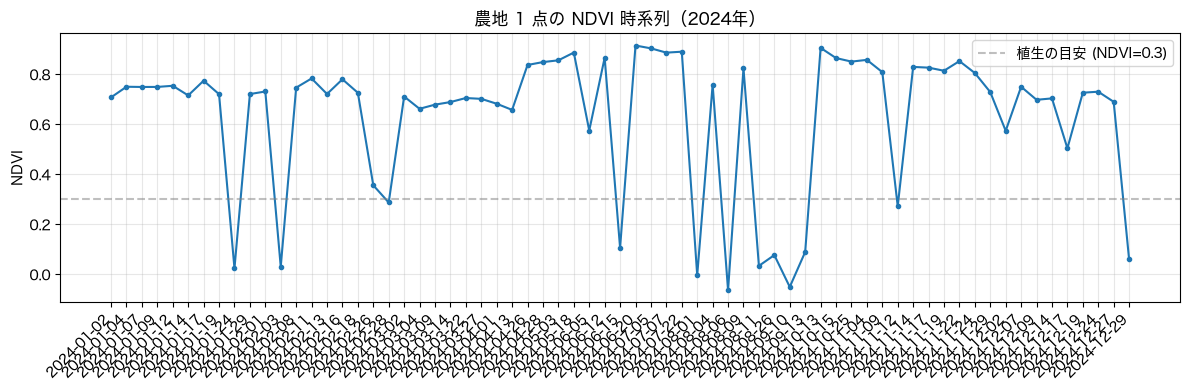

データ点数: 67
NDVI 最大: 0.915, 最小: -0.064


In [ ]:
# 農地上の 1 点を選ぶ

# 2024 年 1 月〜12 月の全画像を取得
ts_collection = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2024-01-01', '2024-12-31')
    .filterBounds(FARM_POINT)
    .filterMetadata('CLOUDY_PIXEL_PERCENTAGE', 'less_than', 60)
    .map(lambda img: img.normalizedDifference(['B8', 'B4']).rename('NDVI').copyProperties(img, ['system:time_start']))
)

# NDVI 値を時系列で抽出
def extract_ndvi(image):
    nd = image.reduceRegion(
        reducer=ee.Reducer.first(),
        geometry=FARM_POINT,
        scale=10
    ).get('NDVI')
    date = image.date().format('YYYY-MM-dd')
    return ee.Feature(None, {'date': date, 'NDVI': nd})

try:
    features = ts_collection.map(extract_ndvi).getInfo()['features']
    dates = []
    values = []
    for f in features:
        props = f['properties']
        if props.get('NDVI') is not None:
            dates.append(props['date'])
            values.append(props['NDVI'])

    if len(dates) > 0:
        plt.figure(figsize=(12, 4))
        plt.plot(dates, values, marker='o', linestyle='-', markersize=3)
        plt.xticks(rotation=45, ha='right')
        plt.ylabel('NDVI')
        plt.title('農地 1 点の NDVI 時系列（2024年）')
        plt.axhline(y=0.3, color='gray', linestyle='--', alpha=0.5, label='植生の目安 (NDVI=0.3)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        print(f'データ点数: {len(dates)}')
        print(f'NDVI 最大: {max(values):.3f}, 最小: {min(values):.3f}')
    else:
        print('有効なデータがありません。別の地点や期間を試してみよう。')
except Exception as e:
    print(f'エラーが発生しました: {e}')
    print('GEE の利用制限に達した可能性があります。少し待ってから再実行してください。')

# 考察（必須）:
# Q1. NDVI のピークはいつか？
# Q2. 雲の影響でデータが欠損している時期はあるか？
# Q3. NDVIが突然0に近い値になっている時期があれば、
#     それは「収穫後」「雲の影響」「センサの異常」のどれが原因か、
#     撮影日と季節から推定せよ。
# Q4. このグラフの農地が「休耕地」だった場合、
#     グラフの形はどう変わるはずか？説明せよ。
#     （休耕地は草地化するため植生はゼロではないが、
#      水稲特有のピークパターンが現れない）
# → ここに考察を書く


---
### ⭐ C4: NDVI 閾値分類による簡易土地被覆図

**ねらい:** NDVI の値に応じて土地を「植生」「裸地」「水域」に分類し、それぞれの面積割合を計算する。
**本タスクとの関係:** 面的な植生状況を定量評価する基礎。休耕地は「裸地」として検出される候補になる。

=== 土地被覆分類のピクセル数 ===
水域 (Water): 1167.9882352941177 ピクセル (0.5%)
裸地 (Bare): 62715.23921568627 ピクセル (27.0%)
植生 (Vegetation): 168510.78039215715 ピクセル (72.5%)
分類画像を取得中...


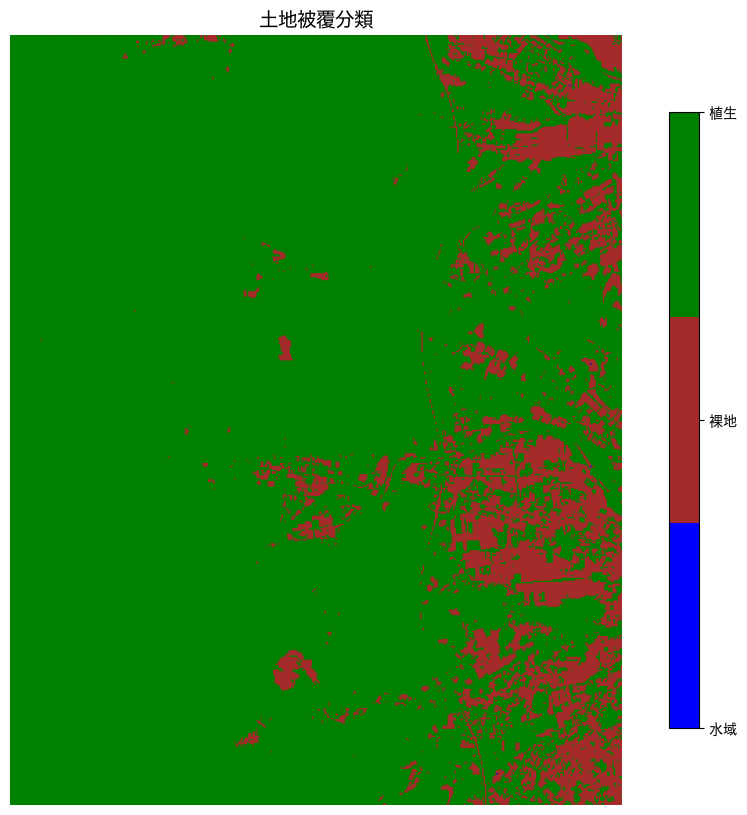

In [ ]:
# NDVI の値に応じて 3 クラスに分類
# ★ EETODO: 閾値を自分で設定せよ（STEP 4のスペクトルカーブを参照）

THRESHOLD_WATER = -0.1   # 水域と裸地の境界（スペクトルカーブから推定）
THRESHOLD_VEG   = 0.3   # 裸地と植生の境界（スペクトルカーブから推定）

water = ndvi.lt(THRESHOLD_WATER).rename('water')
bare = ndvi.gte(THRESHOLD_WATER).And(ndvi.lte(THRESHOLD_VEG)).rename('bare')
veg = ndvi.gt(THRESHOLD_VEG).rename('veg')

# 分類画像を合成（1=水域, 2=裸地, 3=植生）
classified = water.multiply(1).add(bare.multiply(2)).add(veg.multiply(3)).rename('classified')

# 各クラスのピクセル数を集計
area_stats = classified.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=ROI,
    scale=100,
    bestEffort=True
).getInfo()

print('=== 土地被覆分類のピクセル数 ===')
class_names = {1: '水域 (Water)', 2: '裸地 (Bare)', 3: '植生 (Vegetation)'}
total = 0
for k, v in area_stats['classified'].items():
    total += v
for k, v in sorted(area_stats['classified'].items()):
    name = class_names.get(int(k), f'クラス{k}')
    print(f'{name}: {v} ピクセル ({v/total*100:.1f}%)')

print('分類画像を取得中...')
class_arr = geemap.ee_to_numpy(classified, region=DISPLAY_ROI, bands=['classified'], scale=20)
class_arr_2d = class_arr.squeeze()

cmap_class = plt.matplotlib.colors.ListedColormap(['blue', 'brown', 'green'])
plt.figure(figsize=(12, 10))
plt.imshow(class_arr_2d, cmap=cmap_class, vmin=1, vmax=3)
cbar = plt.colorbar(ticks=[1, 2, 3], shrink=0.8)
cbar.ax.set_yticklabels(['水域', '裸地', '植生'])
plt.title('土地被覆分類', fontsize=14)
plt.axis('off')
plt.show()

---
### ⭐ C5: 任意の農地区画を囲んで NDVI 統計取得

**ねらい:** 地図上に長方形を描き、その範囲内の NDVI 平均値などを計算する。
**本タスクとの関係:** 実際の農地ポリゴン（農水省データ）を使った解析の予行演習。個別圃場単位の NDVI 統計は、休耕判定の基本単位になる。

=== 選択範囲の NDVI 統計 ===
NDVI_max: 0.900
NDVI_mean: 0.611
NDVI_min: -0.042
NDVI_stdDev: 0.249

▶ 判定: 植生あり（作付け中 or 自然植生）

解析対象領域を RGB 画像で確認中...


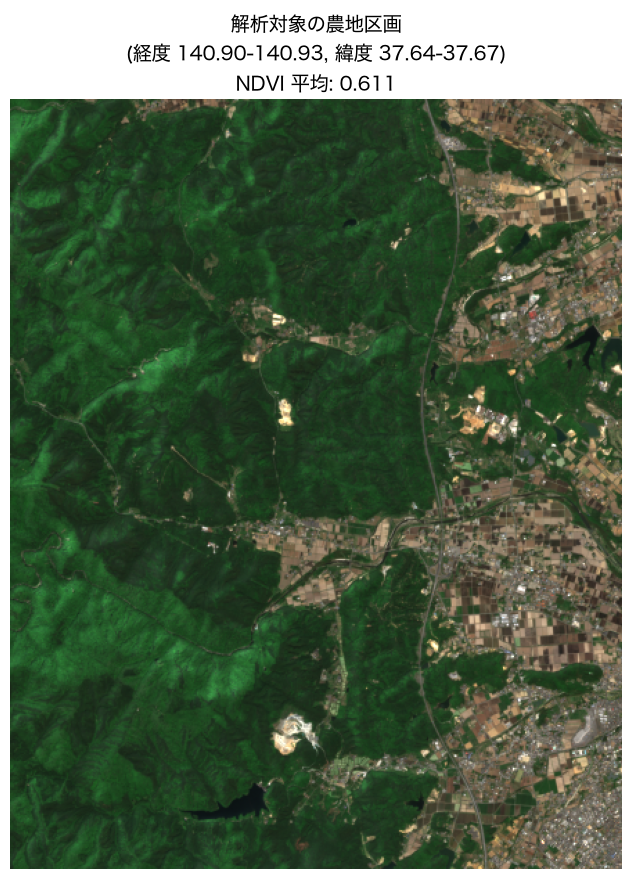

In [ ]:
# 事前に定義した農地区画を解析対象とする
# その範囲内の NDVI 統計を計算
ndvi_stats = ndvi.reduceRegion(
    reducer=ee.Reducer.mean().combine(ee.Reducer.stdDev(), None, True).combine(ee.Reducer.minMax(), None, True),
    geometry=FARM_PLOT,
    scale=10,
    bestEffort=True
).getInfo()

print('=== 選択範囲の NDVI 統計 ===')
for k, v in ndvi_stats.items():
    val_str = f'{v:.3f}' if v is not None else 'N/A'
    print(f'{k}: {val_str}')

# 植生の有無を簡易判定
mean_ndvi = ndvi_stats.get('NDVI_mean')
if mean_ndvi is None:
    print('\n▶ 判定: データなし（領域内に有効ピクセルがありません）')
elif mean_ndvi > 0.3:
    print('\n▶ 判定: 植生あり（作付け中 or 自然植生）')
elif mean_ndvi > -0.1:
    print('\n▶ 判定: 裸地 or 低植生（収穫後・休耕の可能性）')
else:
    print('\n▶ 判定: 水域')
# 対象領域を RGB 画像で確認
print('\n解析対象領域を RGB 画像で確認中...')
rgb_arr = geemap.ee_to_numpy(image, region=DISPLAY_ROI, bands=['B4', 'B3', 'B2'], scale=20)
rgb_display = np.clip(rgb_arr / 3000, 0, 1)
plt.figure(figsize=(12, 10))
plt.imshow(rgb_display)
ndvi_label = f'{mean_ndvi:.3f}' if mean_ndvi is not None else 'N/A'
plt.title('解析対象の農地区画\n(経度 140.90-140.93, 緯度 37.64-37.67)\nNDVI 平均: {}'.format(ndvi_label), fontsize=14)
plt.axis('off')
plt.show()


In [ ]:
# このセルは不要になりました（上のセルで全て実行済み）
print('✅ C5 完了: 農地区画の NDVI 統計を計算しました。上の結果を確認してください。')

✅ C5 完了: 農地区画の NDVI 統計を計算しました。上の結果を確認してください。


### 3 つのチェック

- ✓ **問い**: 衛星にどう見えるか？ → 反射スペクトルの形が地物を区別する。
- ✓ **原理**: NDVI の意味と使える範囲 → 葉緑素と細胞間空隙の構造から説明できる。
- ✓ **限界**: 光学で判断できないケース → 雲・夜間・収穫後の混同・季節変動の4つ。

---
## 次回予告 — Week 2: SAR で同じ農地を見る

今回学んだ「収穫後の農地と休耕地が光学で区別できない問題」—— SAR はどうやってこれを補うのか？

| 光学の弱点 | SAR でどう補うか |
|-----------|----------------|
| 雲を通り抜けられない | マイクロ波は雲を透過する → **全天候型観測** |
| 太陽光が必要 | 自らマイクロ波を照射する → **昼夜観測可能** |
| 裸地と休耕の区別が困難 | 後方散乱のメカニズムの違いで区別できる可能性 |
| 季節変動に左右される | SAR は構造情報を捉える → 季節を超えた変化検出に有効 |

**Week 2 では SAR 画像の見え方と散乱メカニズムを学ぶ。**

---
## Exercise Log の提出

### 提出期限
- **7/22（火）** までに `submissions/個人フォルダ/week1.md` に提出

### 記入内容

**① 必須：以下の2点を自分の言葉で説明**
- Q1. 7月（生育期）と10月（収穫後）のNDVI値はどう変わるか？
- Q2. 収穫後の農地と休耕地を光学だけで区別しようとすると、なぜ失敗するのか？

**② AIを使った場合のみ：AIに同じNDVIコードを書かせ、B4（Red）・B8（NIR）のバンドインデックス指定が一致するか確認し差異を記録**

**⭐ 発展課題（いずれか1つ以上）：**
- (a) NDVI値域が-1〜1に収まっているか確認し、外れていたら原因を推測
- (b) EVIの式を調べ、NDVIと何が違うかを物理的根拠から説明


### 提出方法

**方法A: GitHub に push（VSCode などローカル環境）**
1. `git switch submissions` で submissions ブランチに移動（←重要）
2. `submissions/individual/自分の名前/` ディレクトリを作成（例: `kanda`）
3. その週の資料やコードを `submissions/individual/自分の名前/weekN.md` に作成
4. `git add` / `git commit -m "Week N の回答"` / `git push origin submissions`
詳細は [WORKFLOW.md](https://github.com/astrocamp-2026-siaPpts/astrocamp-2026-sia/blob/main/WORKFLOW.md) を参照。

**方法B: Google Colab / Google Docs で作成**
作成したファイルやリンクを Discord `#weekly-task` チャンネルに共有。

> GitHub の用語がわからない場合は [github-guide.md](https://github.com/astrocamp-2026-siaPpts/astrocamp-2026-sia/blob/main/resources/github-guide.md) を参照。


---
### 【解答例】必須課題の回答

**Q1. 7月（生育期）と10月（収穫後）のNDVI値はどう変わるか？**

7月（生育期）: イネが繁茂しクロロフィル活性が最大になるため、NDVIは0.6〜0.9程度の高い値を示す。
これは葉緑素による赤色光の強い吸収と、葉内部の海綿状組織による近赤外光の強い反射が同時に起きるためである。

10月（収穫後）: 収穫により植生が除去され、地表はわらや裸地になる。NDVIは0.2〜0.3程度まで低下する。
赤色光の吸収が減り、近赤外光の反射も低下するため、植生指標としての値が小さくなる。

**変化の要因**: NDVIの上昇・低下は、植物のクロロフィル量と葉面積指数(LAI)の季節変化を直接反映している。
この「山型」の時系列パターンが、作付け水田の特徴である。

---

**Q2. 収穫後の農地と休耕地を光学だけで区別しようとすると、なぜ失敗するのか？**

収穫後の農地も休耕地も、NDVIは0.2〜0.3程度の「低い値」になるため、**1時期の光学画像だけでは両者の区別が不可能**である。

**失敗する理由**:
1. **NDVIの値だけが判断材料**: 光学センサが捉えられるのは地表の反射スペクトルのみ。NDVIが低い理由が「収穫したから」なのか「もともと何も植えていないから」なのか、スペクトル情報だけでは原因を特定できない。
2. **色情報の類似**: 収穫後のわらや裸地と、休耕地の乾燥した雑草・裸地は、可視光〜近赤外域の反射特性が似通っている。
3. **解決策**: (a) 複数時期のNDVI時系列を比較して「ピークの有無」を見る (b) SARの構造情報で湛水イベントや収穫イベントを検出する

**教訓**: 光学は「今の状態」を色で教えてくれるが、「なぜその状態なのか」の原因まではわからない。この限界をSARが補う。
